# Three models With XGBoost : Beginner - Intermediate - Advanced

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split


## Loading dataset

In [2]:
df_train = pd.read_csv('Marathon_dataset/train.csv')

In [3]:
df_train.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [4]:
df_prep = df_train.copy()
df_prep.head()

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


## Columns to drop anyway

In [5]:
# Target eventually keeping for pro ?
df_train = df_train.drop(columns=['target_finish_time_minutes', 'runner_id', 'marathon_date', 'weekly_mileage_miles'])

# Preprocessing

In [6]:
df_prep = df_train.copy()
df_prep.head()

,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,runs_per_week,long_run_distance_km,...,weather_condition_training_pct,goal_completion_rate,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_weather,course_difficulty,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,25,Male,48,0,Intermediate,4,NaN,20.0,5,15.0,...,12,60,0,70,29,Hot,Mixed,297.0,5,0
1,43,Female,151,2,Advanced,1,196.0,20.0,5,15.0,...,4,64,0,94,0,Sunny,Mixed,231.0,7,1
2,32,Female,82,3,Advanced,6,211.0,23.1,6,15.0,...,30,81,54,47,39,Rainy,Flat,234.0,9,1
3,57,Male,6,0,Beginner,8,NaN,27.3,5,15.0,...,48,59,63,77,45,Sunny,Hilly,276.0,3,3
4,54,Female,11,0,Beginner,3,NaN,20.0,5,15.0,...,5,62,20,64,40,Cloudy,Mixed,296.0,8,0


In [7]:
df_prep = df_prep.drop_duplicates()
df_prep = df_prep.dropna(subset=['actual_finish_time_minutes'])


cols_median = ['personal_best_minutes', 'vo2_max', 'cross_training_hours_per_week']
for col in cols_median:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

cols_avg = ['sleep_hours_avg', 'nutrition_score', 'hydration_consistency']
for col in cols_avg:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mean())

df_prep['injury_severity'] = df_prep['injury_severity'].fillna(0)

In [8]:
(df_prep.isna().sum() / len(df_prep) * 100)[df_prep.isna().sum() > 0].round(2)

Series([], dtype: float64)

## Encoding

In [9]:
# 1. Ordinal mappings
training_map = {"Beginner": 1, "Intermediate": 2, "Advanced": 3}
course_map = {"Flat": 1, "Mixed": 2, "Hilly": 3}
injury_map = {"Minor": 1, "Moderate": 2, "Severe": 3}

df_prep['training_program'] = df_prep['training_program'].map(training_map)
df_prep['course_difficulty'] = df_prep['course_difficulty'].map(course_map)
df_prep['injury_severity'] = df_prep['injury_severity'].map(injury_map).fillna(0)

# 2. Nominal — one-hot on full df
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe.fit_transform(df_prep[['gender', 'marathon_weather']])
ohe_df = pd.DataFrame(ohe_array,
                      columns=ohe.get_feature_names_out(['gender', 'marathon_weather']),
                      index=df_prep.index)

df_prep = df_prep.drop(columns=['gender', 'marathon_weather'])
df_prep = pd.concat([df_prep, ohe_df], axis=1)

# Splitting X and y

In [10]:
df_prep.columns

Index(['age', 'running_experience_months', 'previous_marathon_count',
       'training_program', 'motivation_level', 'personal_best_minutes',
       'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km',
       'speed_work_sessions_per_week', 'rest_days_per_week',
       'training_adherence_pct', 'consecutive_weeks_no_miss',
       'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max',
       'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count',
       'injury_severity', 'nutrition_score', 'hydration_consistency',
       'training_streak_days', 'missed_workout_pct',
       'early_morning_run_frequency', 'weather_condition_training_pct',
       'goal_completion_rate', 'run_club_attendance_rate',
       'warmup_adherence_pct', 'stretching_adherence_pct', 'course_difficulty',
       'actual_finish_time_minutes', 'mental_preparation_score',
       'medal_outcome', 'gender_Male', 'gender_Non-binary',
       'marathon_weather_Cold', 'marathon_weather_Hot',
       

In [11]:
X = df_prep.drop(columns=['actual_finish_time_minutes'])
y = df_prep['actual_finish_time_minutes']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Scaling data

In [13]:
ss_scaler = StandardScaler()

In [14]:
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

# Initializing model

In [69]:
# I don't think it's the fine-tuned
def initialize_model():
    x = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
    return x

In [16]:
model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


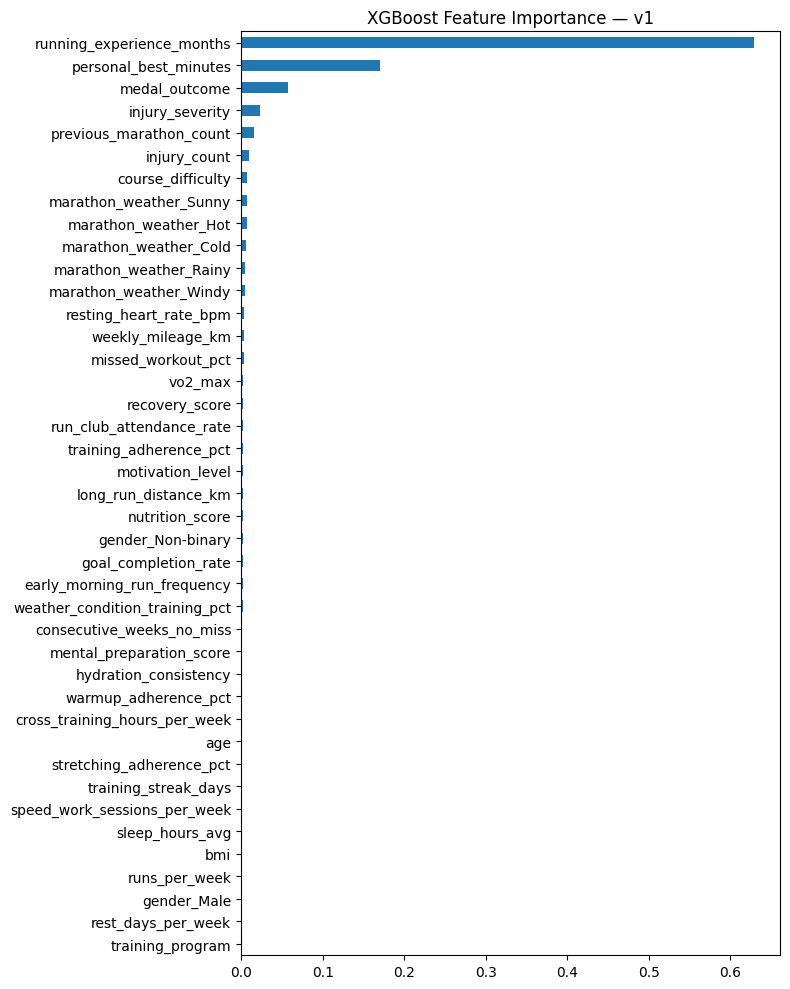

In [17]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [18]:
feat_importance[feat_importance > 0.01].sort_values(ascending=False)

running_experience_months    0.629503
personal_best_minutes        0.170752
medal_outcome                0.057330
injury_severity              0.023608
previous_marathon_count      0.016218
dtype: float32

In [19]:
y_pred_xgb = model.predict(X_test_scaled)

In [20]:
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  10.56 minutes
RMSE: 13.48 minutes
R²:   0.8395


# Test Model (Drop target & Test With the 5 best features)

In [21]:
df_prep.columns

Index(['age', 'running_experience_months', 'previous_marathon_count',
       'training_program', 'motivation_level', 'personal_best_minutes',
       'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km',
       'speed_work_sessions_per_week', 'rest_days_per_week',
       'training_adherence_pct', 'consecutive_weeks_no_miss',
       'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max',
       'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count',
       'injury_severity', 'nutrition_score', 'hydration_consistency',
       'training_streak_days', 'missed_workout_pct',
       'early_morning_run_frequency', 'weather_condition_training_pct',
       'goal_completion_rate', 'run_club_attendance_rate',
       'warmup_adherence_pct', 'stretching_adherence_pct', 'course_difficulty',
       'actual_finish_time_minutes', 'mental_preparation_score',
       'medal_outcome', 'gender_Male', 'gender_Non-binary',
       'marathon_weather_Cold', 'marathon_weather_Hot',
       

In [23]:
X_v2 = df_prep[['running_experience_months', 'medal_outcome', 'injury_severity', 'personal_best_minutes', 'previous_marathon_count']]
y_v2 = df_prep['actual_finish_time_minutes']

In [24]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.1, random_state=42)

In [25]:
X_train_scaled_v2 = ss_scaler.fit_transform(X_train_v2)
X_test_scaled_v2 = ss_scaler.transform(X_test_v2)

In [26]:
model_v2 = initialize_model()
model_v2.fit(X_train_scaled_v2, y_train_v2)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


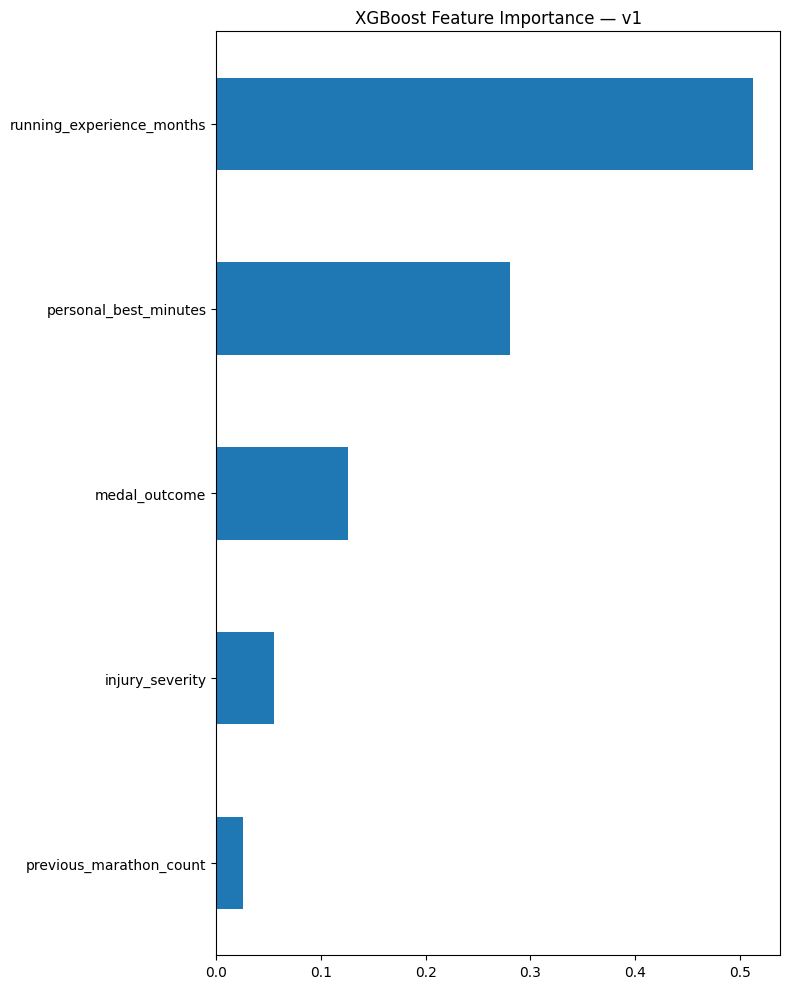

In [27]:
feat_importance_v2 = pd.Series(
    model_v2.feature_importances_,
    index=X_train_v2.columns
).sort_values(ascending=True)

feat_importance_v2.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [28]:
y_pred_xgb_v2 = model_v2.predict(X_test_scaled_v2)

In [29]:
print(f"MAE:  {mean_absolute_error(y_test_v2, y_pred_xgb_v2):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_v2, y_pred_xgb_v2)):.2f} minutes")
print(f"R²:   {r2_score(y_test_v2, y_pred_xgb_v2):.4f}")

MAE:  10.91 minutes
RMSE: 13.93 minutes
R²:   0.8287


# Testing With Columns Beginner Knows (i.e. no mesurement metrics)

In [30]:
df_prep.columns

Index(['age', 'running_experience_months', 'previous_marathon_count',
       'training_program', 'motivation_level', 'personal_best_minutes',
       'weekly_mileage_km', 'runs_per_week', 'long_run_distance_km',
       'speed_work_sessions_per_week', 'rest_days_per_week',
       'training_adherence_pct', 'consecutive_weeks_no_miss',
       'cross_training_hours_per_week', 'resting_heart_rate_bpm', 'vo2_max',
       'bmi', 'recovery_score', 'sleep_hours_avg', 'injury_count',
       'injury_severity', 'nutrition_score', 'hydration_consistency',
       'training_streak_days', 'missed_workout_pct',
       'early_morning_run_frequency', 'weather_condition_training_pct',
       'goal_completion_rate', 'run_club_attendance_rate',
       'warmup_adherence_pct', 'stretching_adherence_pct', 'course_difficulty',
       'actual_finish_time_minutes', 'mental_preparation_score',
       'medal_outcome', 'gender_Male', 'gender_Non-binary',
       'marathon_weather_Cold', 'marathon_weather_Hot',
       

## Columns to drop
(bmi kept because easy to calculate)

In [36]:
drop_list_beginner = ['previous_marathon_count',
                      'training_program',
                      'personal_best_minutes',
                      'resting_heart_rate_bpm',
                      'vo2_max',
                      'medal_outcome',
                      ]

In [37]:
df_begin = df_prep.drop(columns=drop_list_beginner)

In [38]:
X_begin = df_begin.drop(columns=['actual_finish_time_minutes'])
y_begin = df_begin['actual_finish_time_minutes']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_begin, y_begin, test_size=0.1, random_state=42)

In [40]:
ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

In [41]:
model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


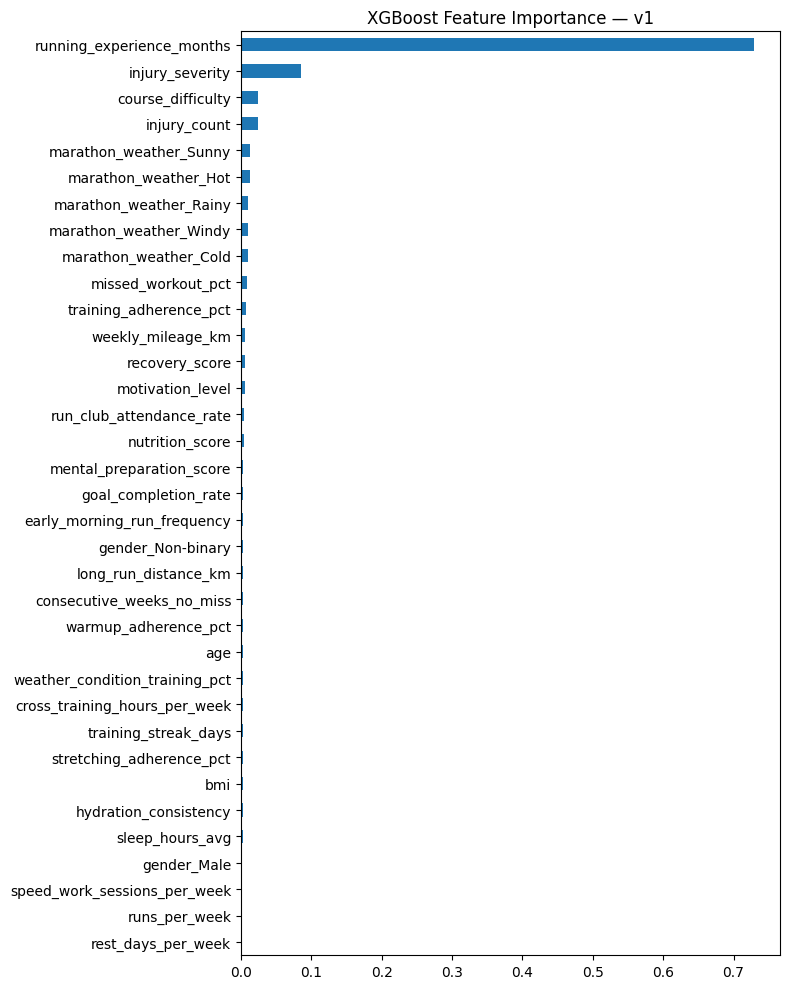

In [42]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [43]:
feat_importance[feat_importance > 0.01].sort_values(ascending=False)

running_experience_months    0.729585
injury_severity              0.084541
course_difficulty            0.023872
injury_count                 0.023581
marathon_weather_Sunny       0.012593
marathon_weather_Hot         0.012559
dtype: float32

In [44]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  16.23 minutes
RMSE: 20.36 minutes
R²:   0.6340


In [45]:
X_begin = df_prep[['running_experience_months',
                   'injury_severity',
                   'course_difficulty']]
y_begin = df_prep['actual_finish_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X_begin, y_begin, test_size=0.1, random_state=42)

ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


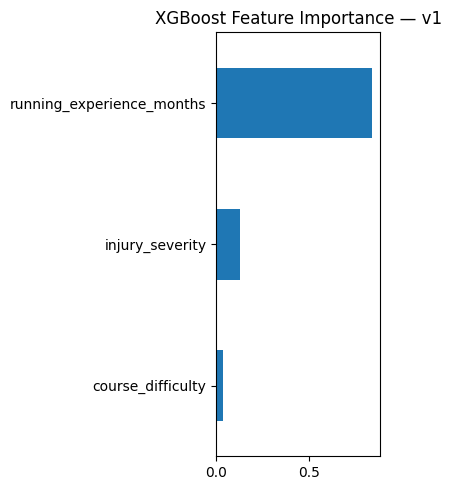

In [46]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(4, 5))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [47]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  16.88 minutes
RMSE: 21.15 minutes
R²:   0.6049


# Testing Columns For Intermediate (i.e. Beginner with Metrics)

In [49]:
drop_list_int = ['previous_marathon_count',
                 'training_program',
                 'personal_best_minutes',
                 'medal_outcome']

In [50]:
df_int = df_prep.drop(columns=drop_list_int)
X_int = df_int.drop(columns=['actual_finish_time_minutes'])
y_int = df_int['actual_finish_time_minutes']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X_int, y_int, test_size=0.1, random_state=42)

ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


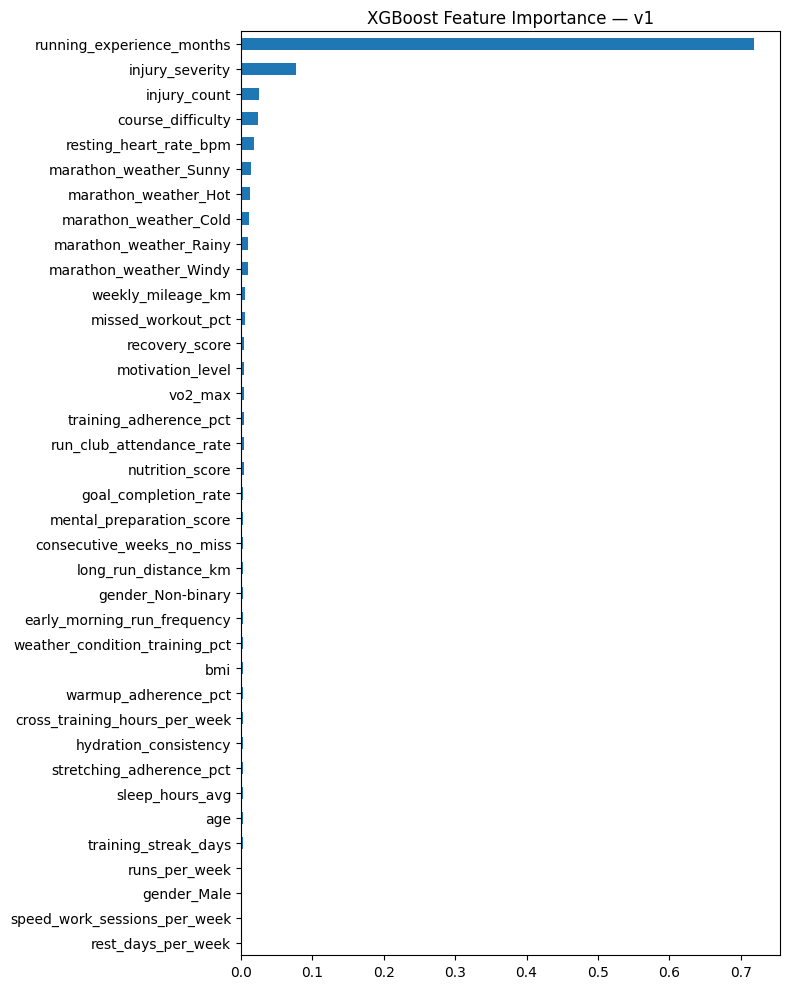

In [52]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [53]:
#Going more precise : importance > 0.005
feat_importance[feat_importance > 0.005].sort_values(ascending=False)

running_experience_months    0.719289
injury_severity              0.077496
injury_count                 0.025115
course_difficulty            0.024115
resting_heart_rate_bpm       0.017712
marathon_weather_Sunny       0.013650
marathon_weather_Hot         0.012192
marathon_weather_Cold        0.011490
marathon_weather_Rainy       0.009383
marathon_weather_Windy       0.009215
weekly_mileage_km            0.005648
missed_workout_pct           0.005259
dtype: float32

In [54]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  16.13 minutes
RMSE: 20.26 minutes
R²:   0.6375


In [55]:
X_int = df_prep[['running_experience_months',
                   'injury_severity',
                   'injury_count',
                   'course_difficulty',
                   'resting_heart_rate_bpm',
                   'weekly_mileage_km',
                   'missed_workout_pct']]
y_int = df_prep['actual_finish_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X_int, y_int, test_size=0.1, random_state=42)

ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


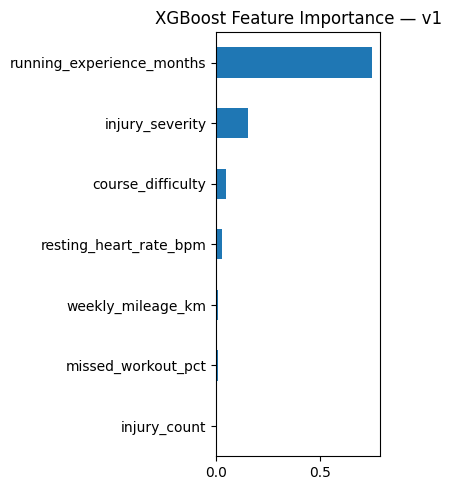

In [56]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(4, 5))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [57]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  16.39 minutes
RMSE: 20.55 minutes
R²:   0.6270


# Testing for Advanced (Actually same as first one)

In [70]:
X_adv = df_prep.drop(columns=['actual_finish_time_minutes'])
y_adv = df_prep['actual_finish_time_minutes']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X_adv, y_adv, test_size=0.1, random_state=42)

ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


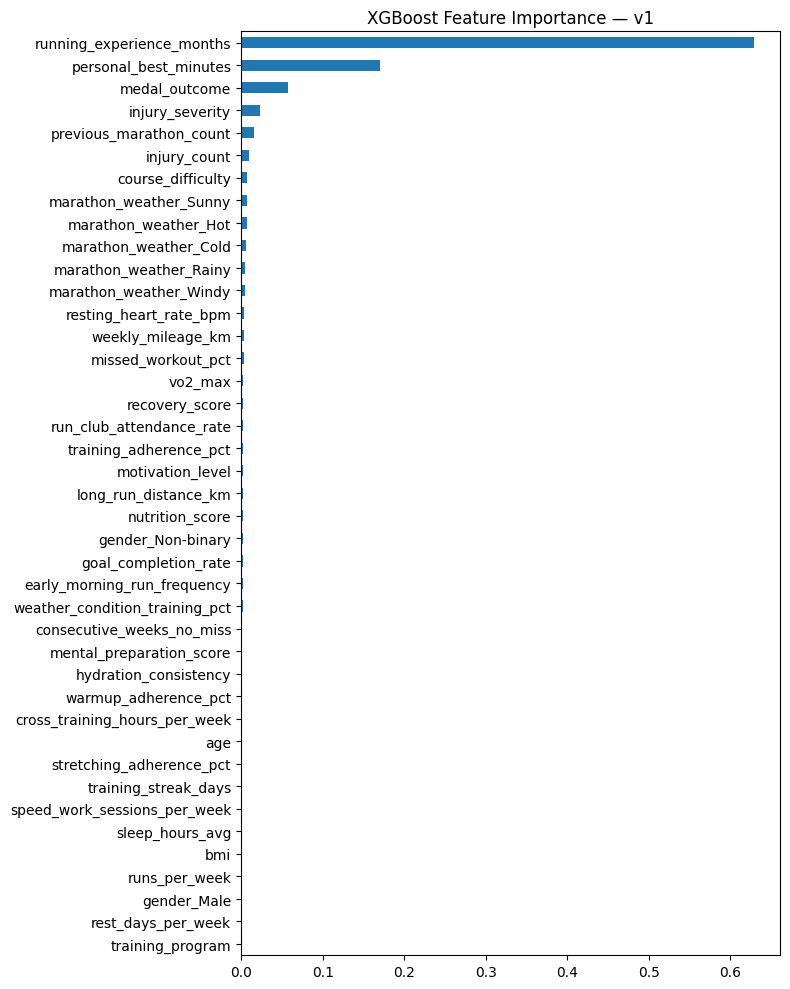

In [72]:
# Plot feature importance
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [73]:
# More precise: importance > 0.0025
feat_importance[feat_importance > 0.0025].sort_values(ascending=False)

running_experience_months    0.629503
personal_best_minutes        0.170752
medal_outcome                0.057330
injury_severity              0.023608
previous_marathon_count      0.016218
injury_count                 0.009720
course_difficulty            0.007338
marathon_weather_Sunny       0.007210
marathon_weather_Hot         0.006850
marathon_weather_Cold        0.005952
marathon_weather_Rainy       0.005387
marathon_weather_Windy       0.005244
resting_heart_rate_bpm       0.004005
weekly_mileage_km            0.003611
missed_workout_pct           0.003161
vo2_max                      0.002824
recovery_score               0.002796
dtype: float32

In [74]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  10.56 minutes
RMSE: 13.48 minutes
R²:   0.8395


In [75]:
X_adv = df_prep[['running_experience_months',
                 'personal_best_minutes',
                 'medal_outcome',
                   'injury_severity',
                   'injury_count',
                   'previous_marathon_count',
                   'course_difficulty',
                   'resting_heart_rate_bpm',
                   'weekly_mileage_km',
                   'missed_workout_pct',
                   'vo2_max',
                   'recovery_score']]

y_adv = df_prep['actual_finish_time_minutes']

X_train, X_test, y_train, y_test = train_test_split(X_adv, y_adv, test_size=0.1, random_state=42)

ss_scaler = StandardScaler()
X_train_scaled = ss_scaler.fit_transform(X_train)
X_test_scaled = ss_scaler.transform(X_test)

model = initialize_model()
model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


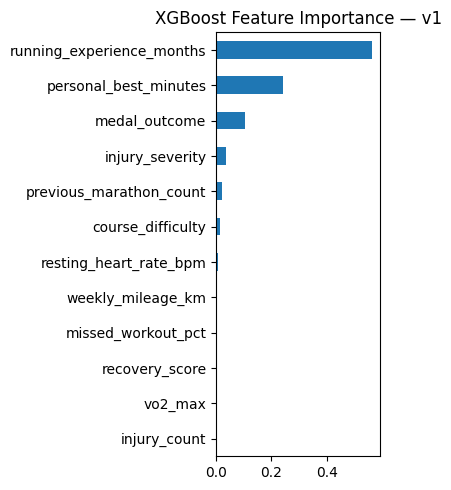

In [76]:
feat_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

feat_importance.plot(kind='barh', figsize=(4, 5))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('XGBoost Feature Importance — v1')
plt.tight_layout()

In [77]:
y_pred_xgb = model.predict(X_test_scaled)
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f} minutes")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} minutes")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.4f}")

MAE:  10.65 minutes
RMSE: 13.64 minutes
R²:   0.8358
